**Цель домашнего задания**: Изучить основные фичи и возможности библиотеки vllm, более детально изучить как работает квантизация на примере AWQ и некоторые другие методы ускорения моделей.

В данной работе вы глубже познакомитесь с методами ускорения моделей, такими как квантизация и speculative decoding, а также с фреймворком vLLM. Вы научитесь применять эти методы на практике, используя библиотеку vllm и другие инструменты.

### План работ:

- Более детально изучить как работает квантизация на примере AWQ и некоторые другие методы ускорения моделей.
- Глубже познакомиться с методами ускорения моделей, такими как квантизация и speculative decoding.
- Изучить основные фичи и возможности библиотеки vllm.

# Часть 1. Квантизация

### Импортируем библиотеки

In [ ]:
import os
import math
import random
from tqdm.notebook import tqdm, trange
from typing import Mapping
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

import transformers
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset

## Квантование матриц по строкам

### Basic Quantization

**Отображение значений в допустимый диапазон**

Квантование — это процесс отображения входных значений из большого множества в выходные значения из меньшего множества. Например, если мы рассматриваем 4-битное квантование, наши значения представлены 4 битами, что означает, что мы можем представлять значения от 0 до $2^4-1=15$.

 * Чтобы получить квантованное представление, нам нужно уметь отображать значения матрицы в этот диапазон и обратно.
 * По причинам, которые станут важными позже, мы будем выполнять это отображение независимо для каждой строки матрицы.
 * Мы параметризуем отображение следующим образом: $out = \frac{in}{scale} + zero$, где $scale$ и $zero$ являются построчными константами.
 * Для матрицы размером `(m, k)` ($m$ строк, $k$ столбцов) мы агрегируем эти параметры в два вектора `scale` и `zero` размером `(m, 1)`.

**Задание.** Завершите функцию ниже, чтобы выполнить это отображение:

In [ ]:
def get_scale_and_zero(x: Tensor, max_abs: float) -> tuple[Tensor, Tensor]:
    """ Дан тензор x с shape = (m, k) и max_abs > 0, создайте тензоры scale и zero shape = (m, 1)
        такие, что 0 < x / scale + zero < max_abs"""
    # Ваш код здесь
    # max(x)/s + z = max_abs
    # min(x)/s + z = 0
    # z = max_abs - max(x)/s
    # s = - min(x) / z = - min(x) / (max_abs - max(x)/s)
    # s * (max_abs - max(x)/s) = - min(x)
    # s * max_abs -  max(x) = - min(x)
    # s =  ( max(x) - min(x) ) / max_abs

    unique_row = (x == x[:, 0].unsqueeze(1)).all(dim=1)
    max_x, _ = torch.max(x, dim=1)
    min_x , _ = torch.min(x, dim=1)
    scale = (max_x - min_x) / max_abs
    scale.masked_fill_(unique_row, 1)
    zero = max_abs -  max_x / scale
    return scale.reshape(-1,1), zero.reshape(-1,1)


In [ ]:
# Тестирование вашего кода

x = torch.arange(512 * 1024).reshape(512, 1024).float()
scale, zero = get_scale_and_zero(x, 15)
assert scale.shape == (512, 1), "Неправильная shape scale"
assert zero.shape == (512, 1), "Неправильная shape zero"
assert torch.all(scale * 15 <= 1023.1), "Scale не может быть таким большим. Получившийся интервал слишком широк"
assert torch.all(scale * 15 >= 1022.9), "Scale не должен быть таким маленьким. Получившийся интервал слишком узок"
assert torch.all(-0.001 <  x / scale + zero) and torch.all(x / scale + zero < 15 + 0.001)

x = torch.zeros(128, 128)
scale, zero = get_scale_and_zero(x, 15)
assert torch.all(scale == 1) and torch.all(scale * 15 >= 0.99), "Если все значения в строке одинаковы, установим scale равным 1"
print("Все тесты пройдены!")

Все тесты пройдены!


## LLM Quantization

### AWQ

На лекции был разобран алгоритм GPTQ,  далее вам будет предложено более детально ознакомиться как устроен алгоритм AWQ в деталях.

AWQ — это продвинутый алгоритм пост-тренировочного квантования весов, основанный на асимметричном квантовании с вниманием к активациям. Он предназначен для уменьшения потерь точности при квантовании LLM и других глубоких моделей.

В отличие от обычного симметричного квантования, AWQ предлагает несколько ключевых улучшений:
 * Он использует **асимметричное квантование**, позволяющее точнее аппроксимировать распределение весов.
 * Он **перераспределяет масштаб веса** в линейных слоях таким образом, чтобы сохранить важную информацию при меньшем числе бит.
 * Он учитывает **влияние квантованных весов на активации** и корректирует квантованные значения для минимизации ошибки активации.

Более формально, AWQ минимизирует ошибку между неквантованным выходом $Y = XW^T$ и квантованным выходом $Y_q = X\widehat{W}^T$ с учетом шкалирования:
$$
\min_{\widehat{W}, S} \|XW^T - (X\widehat{W}^T) \odot S\|_2^2
$$
где:
 * $X$ — входная матрица,
 * $W$ — оригинальные веса,
 * $\widehat{W}$ — квантованные веса,
 * $S$ — вектор масштабов (scale factors), подбираемый для каждой выходной нейронной функции.

Алгоритм AWQ включает следующие шаги:
1. **Определение важности весов**: для каждого выходного канала вычисляется вклад в финальный выход, что помогает расставить приоритеты.
2. **Асимметричное квантование весов**: используется оптимальное смещение (zero-point) и масштаб, зависящий от конкретной статистики весов.
3. **Оптимизация масштаба выхода**: масштабирование каждого канала оптимизируется для минимизации ошибки между оригинальным и квантованным выходом.
4. **Распределённая реализация**: как и GPTQ, AWQ позволяет построчную параллелизацию, благодаря независимости между выходными каналами.

AWQ реализует стратегию квантования, устойчивую к outlier-весам, и подходит для 4-битного квантования даже на больших языковых моделях (LLama и др.).

Кроме того, AWQ ускоряет инференс, так как совместим с INT4/INT8 аппаратными ускорителями, и улучшает соотношение "качество / размер модели" без необходимости повторной тренировки модели.

**Преимущества AWQ:**
 * Высокая точность при низком числе бит (4-бит, 8-бит).
 * Поддержка больших моделей без fine-tuning.
 * Простая интеграция в существующий стек inference.
 * Открытая реализация и совместимость с Hugging Face и ONNX.

Таким образом, AWQ — это эффективный способ сжать модель без существенной потери качества, с фокусом на реальное влияние весов на выходы.

#### Задание: реализация базовой логики AWQ
AWQ — это асимметричное квантование весов, при котором масштаб (scale) подбирается не просто по min/max весов, а с учетом влияния на выход слоя. Идея — минимизировать разницу между выходами модели с оригинальными и квантованными весами при фиксированном входе X.

Что требуется сделать?
- Реализовать асимметричное квантование весов (quantize_row).

- Реализовать деквантование весов (dequantize_row).

- Реализовать поиск оптимального масштаба (scale) для каждой строки весов: найти такой scale, при котором выход $X\widehat{W}^T$ будет как можно ближе к $XW^T$.

- Реализовать функцию, вычисляющую MSE между настоящим выходом и восстановленным.

- Проверить работу на тестах.

In [ ]:
import numpy as np

def quantize_row(row, scale, zero_point, q_levels=16):
    q_row = np.clip(
        np.round((row - zero_point) / scale),
        0, 2**q_levels - 1).astype(np.int16)
    return q_row

def dequantize_row(q_row, scale, zero_point):
    row = q_row * scale + zero_point
    return row

def forward(X, weights):
    return X @ weights.T

def mse_loss(a, b):
    return np.mean((a - b) ** 2)

def mse_grad(a, b):
    return 2 * (a - b) / a.size

def optimize_scale_by_gradient(X, original_row, zero_point, q_levels=16,
                               init_scale=0.1, lr=1e-2, steps=100):
    scale = init_scale
    n = X.shape[0]  # Количество примеров

    for step in range(steps):
        # Квантование и деквантование
        q_row = quantize_row(original_row, scale, zero_point, q_levels)
        dq_row = dequantize_row(q_row, scale, zero_point)

        # Вычисление выходов
        out_real = forward(X, original_row)
        out_fake = forward(X, dq_row)

        # Вычисление потерь и градиента
        loss = mse_loss(out_real, out_fake)
        grad_out = mse_grad(out_real, out_fake)  # dL/d(out_fake)

        # Градиент по scale (игнорируя производную округления)
        grad_scale = np.sum(grad_out * (X @ q_row))

        # Обновление scale с защитой от отрицательных значений
        scale -= lr * grad_scale
        scale = max(scale, 1e-5)

    return scale

In [ ]:
# Тестовая матрица входов и весов
X = np.eye(5)  # Единичная матрица
weights = np.array([
    [0.5, -0.3, 0.1, 0.2, -0.1],
    [0.4, 0.6, -0.4, 0.0, 0.2],
])

q_levels = 16

for i, row in enumerate(weights):
    zero_point = row.min()

    # Подбираем scale через градиентный спуск
    scale = optimize_scale_by_gradient(
        X, row, zero_point, q_levels, init_scale=0.3, lr=1e-5, steps=2000
    )

    # Проверка 1: scale положителен
    assert scale > 0, f"Scale должен быть положительным, но получен {scale}"

    # Квантование и деквантование
    q_row = quantize_row(row, scale, zero_point, q_levels)
    dq_row = dequantize_row(q_row, scale, zero_point)

    # Проверка 2: квантованные значения в пределах диапазона
    assert np.all((q_row >= 0) & (q_row < 2**q_levels)), \
        f"Некорректные индексы квантования: {q_row}"

    # Проверка 3: ошибка выхода (MSE < 0.01)
    original_out = forward(X, row)
    quantized_out = forward(X, dq_row)
    error = mse_loss(original_out, quantized_out)

    print(f"Строка {i}: MSE в выходных данных: {error:.6f}")
    assert error < 0.01, f"MSE слишком велика: {error}"

    print(f"Тест {i} пройден — scale: {scale:.6f}")
    print("-----------")


Строка 0: MSE в выходных данных: 0.008904
Тест 0 пройден — scale: 0.304250
-----------
Строка 1: MSE в выходных данных: 0.006039
Тест 1 пройден — scale: 0.299122
-----------


# Часть 2. Speculative Decoding



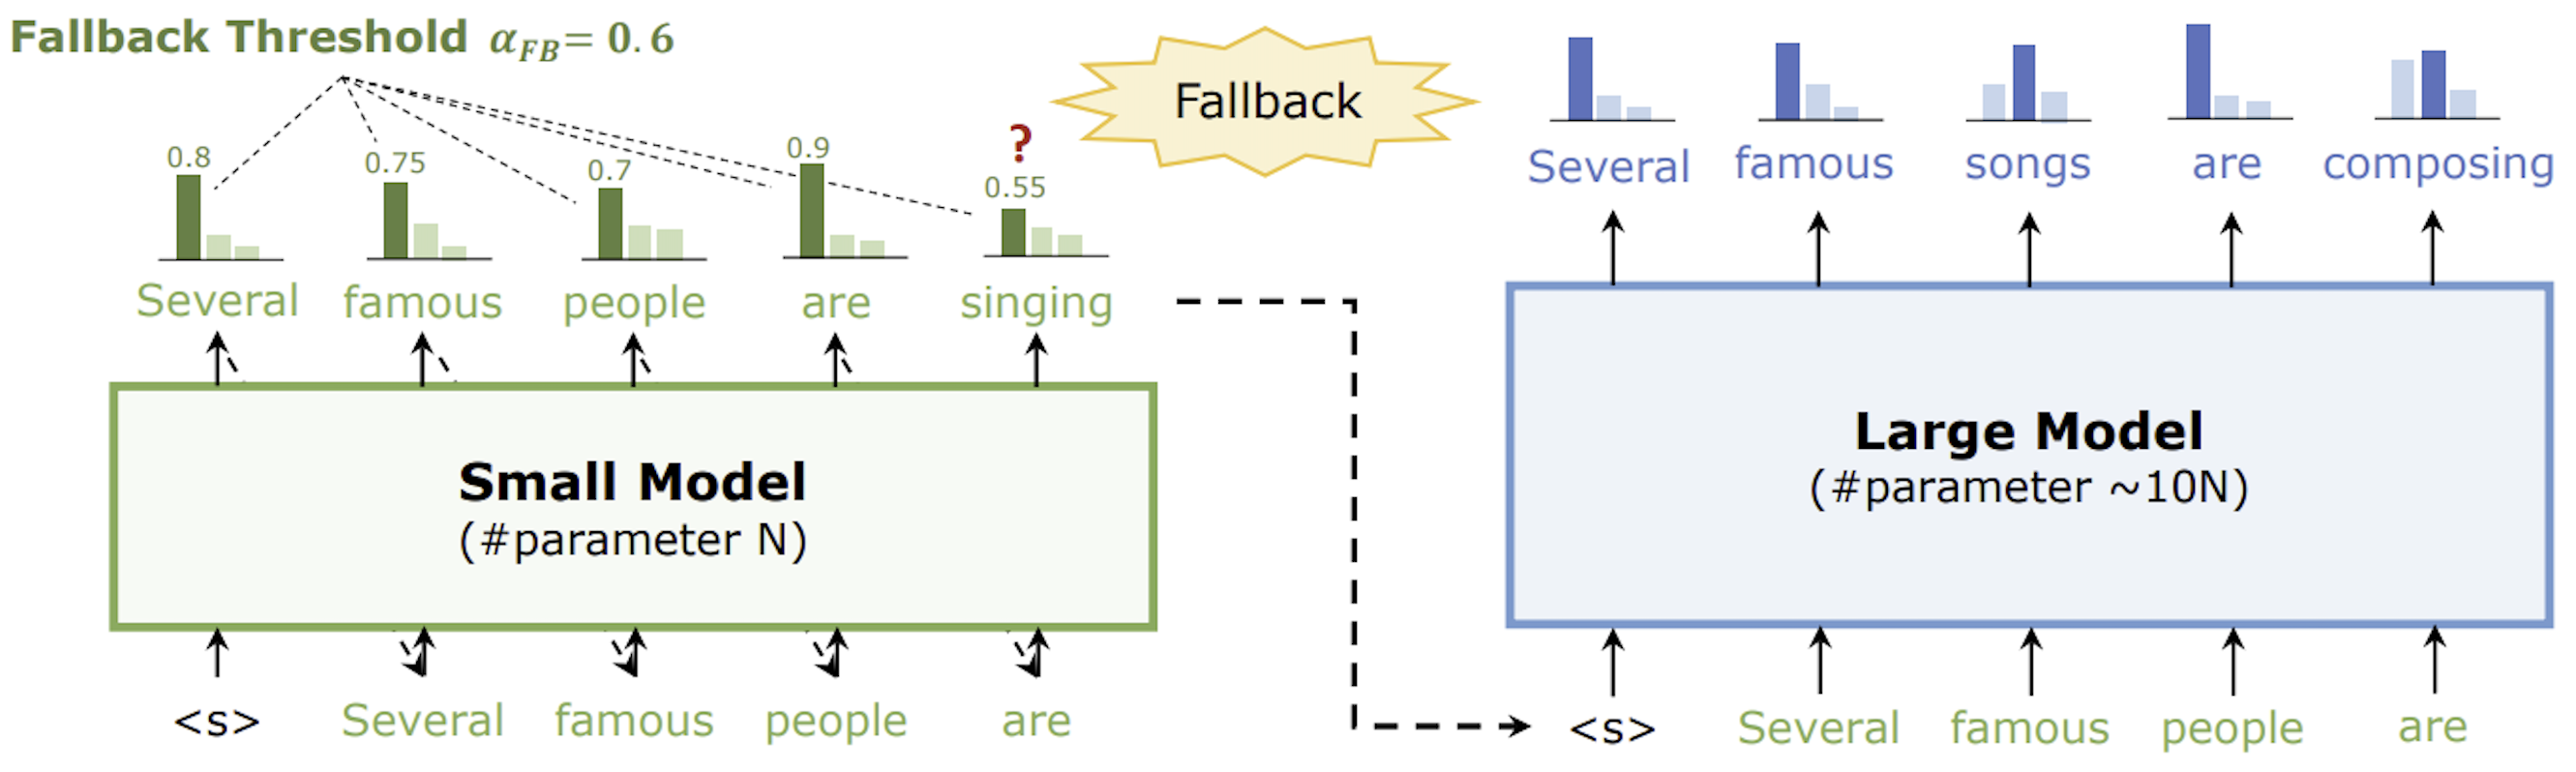

Идея заключается в том, чтобы использовать небольшую и дешевую модель ("draft" model), чтобы сначала сгенерировать последовательность первых k токенов (токенов кандидатов), а затем всю эту последовательность пропускаем через большую модель батчевым образом. По времени это почти также как и один прогон токена большой моделью. Далее идем слева направо по логитам, предсказанным небольшой моделью, и токенам выборки с помоощью большой модели. Любой токен, который согласуется с предсказанным, позволяет немедленно перейти к следующему токену. Если есть какой-то токен не совпадает, то мы отбрасываем предсказание малой модели.

### Использование двух схожих по архитектуре моделей

**Загрузка модели**

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

draft_model = "unsloth/gemma-2-2b-it"
model = AutoModelForCausalLM.from_pretrained(draft_model, torch_dtype=torch.float16, device_map="cuda")
tokenizer = AutoTokenizer.from_pretrained(draft_model)

**Компилируем модель с помощью torch.compile**

библиотека `transformers` не очень эффективна с точки зрения использования вычилительных ресурсов.

Однако с `PyTorch` `v2.0.0` был представлен [`torch.compile`](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html). Эта функция позволяет захватывать, изолировать и оптимизировать среду выполнения CUDA в `PyTorch`. Используя эту функцию, мы можем эффективно устранить почти все накладные расходы на Python и оптимизировать ядра.

Начиная с [`transformers` `v4.44.0`](https://github.com/huggingface/transformers/releases/tag/v4.44.0), эта функция интегрирована с утилитами генерации текста `transformers` от начала до конца. Однако для простоты мы применим его конкретно к прямому проходу модели.

In [ ]:
!pip show torch
!pip show transformers

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
Name: transformers
Version: 4.52.4
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://gi

In [ ]:
model.forward = torch.compile(
    model.forward,
    fullgraph=True,
    mode="reduce-overhead", # Оптимизация скорости
)

**Бенчмарк для forwardpass с разной длиной последовательности**

Запустите следующую ячейку 2 и более раз. Первый запуск будет медленным, так как происходит компиляция.

Последующие запуски будут значительно быстрее.

(ДОПОЛНИТЕЛЬНО: запустите эту ячейку без компиляции, чтобы измерить ускорение компиляции)

In [ ]:
from time import perf_counter

NUM_REPEATS = 100

throughpus = {}

for seq_len in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    input_ids = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to("cuda")

    with torch.no_grad():
        start = perf_counter()
        for _ in range(NUM_REPEATS):
            model(
                input_ids,
                use_cache=False,
            )
            torch.cuda.synchronize()
        end = perf_counter()
    throughpus[seq_len] = NUM_REPEATS * seq_len / (end - start)
    print(f"{seq_len} tokens: {NUM_REPEATS / (end - start):.2f} passes/s")

1 tokens: 40.70 passes/s
2 tokens: 39.34 passes/s
4 tokens: 39.20 passes/s
8 tokens: 38.55 passes/s
16 tokens: 34.90 passes/s
32 tokens: 31.43 passes/s
64 tokens: 28.42 passes/s
128 tokens: 20.20 passes/s
256 tokens: 10.98 passes/s
512 tokens: 6.60 passes/s
1024 tokens: 3.23 passes/s


In [ ]:
#без torch.compile
from time import perf_counter

NUM_REPEATS = 100

throughpus = {}

for seq_len in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    input_ids = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to("cuda")

    with torch.no_grad():
        start = perf_counter()
        for _ in range(NUM_REPEATS):
            model(
                input_ids,
                use_cache=False,
            )
            torch.cuda.synchronize()
        end = perf_counter()
    throughpus[seq_len] = NUM_REPEATS * seq_len / (end - start)
    print(f"{seq_len} tokens: {NUM_REPEATS / (end - start):.2f} passes/s")
# без torch.compile быстрее)))

1 tokens: 11.19 passes/s
2 tokens: 15.46 passes/s
4 tokens: 16.74 passes/s
8 tokens: 9.88 passes/s
16 tokens: 11.81 passes/s
32 tokens: 11.25 passes/s
64 tokens: 10.38 passes/s
128 tokens: 19.46 passes/s
256 tokens: 10.59 passes/s
512 tokens: 5.86 passes/s
1024 tokens: 2.89 passes/s


Как мы видим, скорость прямого прохода почти не зависит от количества токенов, проходящих через модель, до примерно **16** токенов за раз.

Text(0, 0.5, 'Troughput, tokens per second')

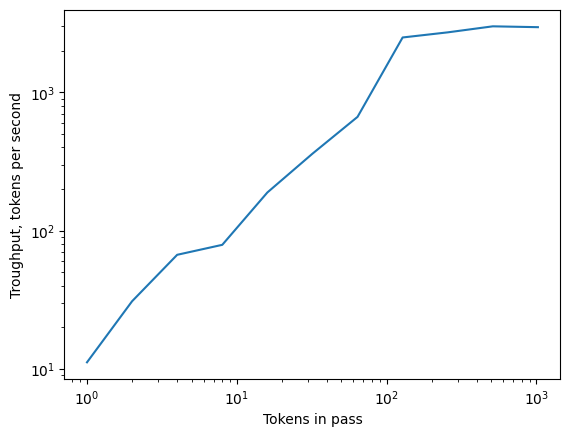

In [ ]:
# посмотрим на график
import matplotlib.pyplot as plt

plt.plot(throughpus.keys(), throughpus.values())
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Tokens in pass")
plt.ylabel("Troughput, tokens per second")

In [ ]:
del model

## Speculative decoding

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
device = "cuda"

# Загрузим маленькую Gemma2 model (шаг - draft generation)
draft_model_name = "unsloth/gemma-2-2b-it"
draft_tokenizer = AutoTokenizer.from_pretrained(draft_model_name, device_map="auto")
draft_model = AutoModelForCausalLM.from_pretrained(draft_model_name, device_map="auto", torch_dtype=torch.bfloat16)

# Загрузим основную Gemma2 model (шаг - verification)
main_model_name = "unsloth/gemma-2-9b-it"
main_tokenizer = AutoTokenizer.from_pretrained(main_model_name, device_map="auto")
main_model = AutoModelForCausalLM.from_pretrained(main_model_name, device_map="auto", torch_dtype=torch.bfloat16)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

**Задание.** Напишем функцию для генерации текста с помощью моделей.

In [2]:
def inference(model, tokenizer, prompt, max_new_tokens=100):
    # Ваш код здесь
    # Результат - это декодируемый из идентификаторов токенов текст
    input_text = prompt
    input_ids = tokenizer(input_text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(**input_ids, max_new_tokens=max_new_tokens)
    return tokenizer.decode(outputs[0][input_ids['input_ids'][0].shape[0]:], skip_special_tokens=True)

In [3]:
inference(draft_model, draft_tokenizer, 'Hi, what is your name?')

'\n\nHi! My name is Gemma. 😊 \n'

In [4]:
inference(main_model, main_tokenizer, 'Hi, my name is')

" Sarah and I'm a certified personal trainer. I'm passionate about helping people achieve their fitness goals, no matter their starting point.\n\nI believe that everyone deserves to feel strong, healthy, and confident in their own body. My approach to training is personalized and holistic, taking into account your individual needs, goals, and lifestyle.\n\nWhether you're looking to lose weight, build muscle, improve your cardiovascular health, or simply feel more energized, I can create a customized workout plan that"

**Задание.** Реализовать метод расчета спекулятивного декодирования через log_likelihood, используя следующие шаги:

1. Генерация чернового варианта: мальнькая модель генерирует черновик текста из заданного промпта.
2. Шаг верификации: большая модель проверяет черновик, вычисляя логарифмическое правдоподобие для каждого токена в черновике.
3. Расчет логарифмического правдоподобия: мы вычисляем среднее логарифмическое правдоподобие, чтобы определить, насколько вероятно, что большая модель считает черновик малой модели правильным.

Логарифм правдоподобия — это логарифм вероятности, которую модель назначает определенной последовательности токенов. Здесь он отражает, насколько вероятно или «уверенно» модель, что последовательность токенов (сгенерированный текст) действительна с учетом предыдущих токенов.

In [5]:
def speculative_decoding_likelihood(draft_model, main_model, draft_tokenizer, main_tokenizer, prompt, max_new_tokens=100):
    # Шаг 1: Сгененрируем ответ малой моделью
    draft_result = inference(draft_model, draft_tokenizer, prompt, max_new_tokens)
    draft = draft_result
    # Шаг 2: Верефицируем результат draft модели с помощью основной модели
    main_inputs = main_tokenizer(prompt + draft_result, return_tensors="pt").to(device)

    # Шаг 3: Рассчитайте среднее логарифмическое правдоподобие токенов draft модели с помощью большой модели
    with torch.no_grad():
        main_outputs = main_model(**main_inputs)
        logits = main_outputs.logits

        shifted_logits = logits[:, :-1, :]
        shifted_labels = main_inputs.input_ids[:, 1:]

        log_probs = torch.nn.functional.log_softmax(shifted_logits, dim=-1)
        token_log_probs = log_probs.gather(2, shifted_labels.unsqueeze(-1)).squeeze(-1)

        prompt_len = len(main_tokenizer(prompt)["input_ids"])
        gen_log_probs = token_log_probs[:, prompt_len - 1 :]  # учёт первого токена генерации

        avg_log_likelihood = token_log_probs.mean().item()

    return draft, avg_log_likelihood

Теперь мы сможем оценить прирост производительности после использования speculative decoding. Мы будем оценивать производительность, исспользуя значение логарифмического правдоподобия. Значение логарифмического правдоподобия, приближающееся около нуля или ниже указывает на то, что сгенерированный текст является точным.

In [6]:
import time

In [7]:
def calculate_latency(draft_model, main_model, draft_tokenizer, main_tokenizer, prompt, max_new_tokens=100):
    # Измерим скорость ответа для простого inference (основная model)
    start_time = time.time()
    normal_output = inference(main_model, main_tokenizer, prompt, max_new_tokens)
    normal_inference_latency = time.time() - start_time
    print(f"Ответ модели: {normal_output}")
    print(f"Скорость ответа: {normal_inference_latency:.4f} секунд")
    print("--------")

    # Измерим скорость ответа для speculative decoding (при условии, что весь сгенерированный текст прошел верефикацию большой моделью)
    start_time = time.time()
    draft_output, log_likelihood = speculative_decoding_likelihood(
        draft_model, main_model, draft_tokenizer, main_tokenizer, prompt, max_new_tokens
    )
    speculative_decoding_latency = time.time() - start_time
    print(f"Speculative Decoding Ответ модели: {draft_output}")
    print(f"Speculative Decoding скорость ответа: {speculative_decoding_latency:.4f} секунд")
    print(f"Log Likelihood: {log_likelihood:.4f}")

    return normal_inference_latency, speculative_decoding_latency

In [8]:
calculate_latency(draft_model, main_model, draft_tokenizer, main_tokenizer, prompt="Data Science is ", max_new_tokens=100)

Ответ модели: 
a multidisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from structured and unstructured data. 

Here's a breakdown of what makes up Data Science:

**Core Components:**

* **Mathematics and Statistics:**  The foundation of data science. It involves understanding probability, distributions, hypothesis testing, regression, and other statistical concepts to analyze data and draw meaningful conclusions.
* **Computer Science:**  Provides the tools and techniques to work with data
Скорость ответа: 2.9201 секунд
--------
Speculative Decoding Ответ модели: 
a rapidly growing field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from structured and unstructured data. 

Here's a breakdown of what that means:

**1. Scientific Methods, Processes, Algorithms, and Systems:**
   - **Scientific methods:**  Data science relies on the scientific method, which involves as

(2.9201300144195557, 1.7332818508148193)

**Задание.** Написать полную функцию генерации полного текста с помощью speculative decoding.

In [9]:
def generate_full_text(draft_model, main_model, draft_tokenizer, main_tokenizer, prompt,
                       max_total_tokens=100, chunk_size=10, log_likelihood_threshold=-3):
    """
    Генерация полного текста с помощью speculative decoding. Останавливается при достижении
    max_total_tokens или если log-likelihood draft ответа ниже порогового значения.
    """
    full_text = prompt
    total_tokens = len(draft_tokenizer(full_text)['input_ids'])
    history = [] # Сохраним историю генерации


    while total_tokens < max_total_tokens:
        # Генерируем черновик маленькой моделью
        draft, avg_log_likelihood = speculative_decoding_likelihood(
            draft_model, main_model, draft_tokenizer, main_tokenizer,
            full_text, max_new_tokens=chunk_size
        )

        # Если качество черновика выше порога, принимаем его
        if avg_log_likelihood >= log_likelihood_threshold:
            new_chank = draft

        else:
            # Если качество плохое, генерируем токен основной моделью
            main_output = inference(
                main_model, main_tokenizer,
                full_text, max_new_tokens=chunk_size)
            new_chank = main_output

        full_text += new_chank
        total_tokens = len(draft_tokenizer(full_text)['input_ids'])

        # Записываем информацию о текущем шаге в историю
        history.append( (draft, avg_log_likelihood) )

        # Проверяем условие остановки по максимальному количеству токенов
        if total_tokens >= max_total_tokens:
            break

        print(total_tokens)
    # Ваш код здесь

    return full_text, history


Протестируем нашу функцию

In [10]:
prompt = "Жил-был один Data Scientist, который "

full_text, steps = generate_full_text(
    draft_model, main_model,
    draft_tokenizer, main_tokenizer,
    prompt=prompt,
    max_total_tokens=150,
    chunk_size=15,
    log_likelihood_threshold=-1.0
)

print("Итоговый текст:")
print(full_text)
print("\nИстория генерации по шагам:")

for i, (chunk, ll) in enumerate(steps):
    print(f"\n Шаг {i + 1}:")
    print(f"Среднее лог-правдоподобие: {ll:.3f}")
    print(f"Добавленный текст: {repr(chunk)}")


26
41
56
71
86
101
116
131
146
Итоговый текст:
Жил-был один Data Scientist, который 
любил свою работу. Он проводил дни, погружаясь в 
данные, выявляя скрытые закономерности и 
создавая модели, которые могли предсказывать 
будущее. 

Но однажды, его мир перевернулся. 
Компания, в которой он работал, решила 
перейти на новую платформу для анализа данных. 
Эта платформа была невероятно мощной, 
но ее интерфейс был сложным и требовал 
значительных усилий для освоения. 

Data Scientist был в шоке. 
Он не мог понять, как его любимая работа 
будет теперь выглядеть. 
Он чувствовал

История генерации по шагам:

 Шаг 1:
Среднее лог-правдоподобие: -3.016
Добавленный текст: '\nочень любил играть в игры. \nОн был мастером в'

 Шаг 2:
Среднее лог-правдоподобие: -2.172
Добавленный текст: ' мир данных, \nиспользуя все свои навыки, чтобы найти скры'

 Шаг 3:
Среднее лог-правдоподобие: -1.422
Добавленный текст: '\nсоздавая модели, которые могли предсказывать будущее. \n'

 Шаг 4:
Среднее лог-правдоподо

In [12]:
del draft_model
del main_model

## Другие варианты

В качестве вспомогательной модели в целом может быть какая-то другая, более сильная модель для speculative decoding:

 * **Большие N-граммные модели**: Можно использовать большие n и больше данных для обучения N-грамных моделей. В противном случае не имеет смысла применять из-за того что ответы малой и большой модели будут слишком расходиться.
 * **Маленькая модель Llama, Mistral, Gemma**: проблема использования LLM в качестве speculative генератора заключается в том, что она должна использовать тот же токенизатор, что и модель верификатор. То есть, ваша маленькая Llama, Mistral или Gemma должна иметь тот же токенизатор.
  * Здесь важно еще дополнительно убедиться, что прямой проход модели действительно незначителен с точки зрения времени генерации гипотезы (время verify >> время speculate).
 * **LSTM**: Можно также попробовать обучить ее с нуля. Вы можете инициализировать слой embedding с помощью эмбеддингов Llama для облегчения сходимости.
 * **word2vec/CBOW**: Ее достаточно обучить на `train_batch` или на любых других данных. Главное, убедитесь, что она использует только предыдущие токены и что контекст длиннее, чем то, что вы хотите предположить.
 * **Широкая спекуляция**: Ваша гипотеза не обязательно должна быть линейной. Вы можете на самом деле предположить дерево возможных следующих токенов и проверить его с помощью одного прохода. Это требует некоторых нетривиальных манипуляций с `attention_mask`. Подробнее можно почитать [здесь](https://arxiv.org/abs/2305.09781) и [здесь](https://huggingface.co/blog/poedator/4d-masks).

# Часть 3. Фреймворк vLLM.

vLLM — быстрая и простая в использовании библиотека для вывода LLM в продакшен. vLLM на данный момент полностью управляется сообществом.

vLLM работает быстро с:

- Современная пропускная способность обслуживания
- Эффективное управление памятью ключей и значений внимания с помощью PagedAttention
- Непрерывная пакетная обработка входящих запросов
- Быстрое выполнение модели с помощью графика CUDA/HIP
- Квантование: GPTQ, AWQ, INT4, INT8 и FP8.
- Оптимизированные ядра CUDA, включая интеграцию с FlashAttention и FlashInfer.
- Speculative Decoding
- Chunked prefill

vLLM гибок и прост в использовании благодаря:

- Полная интеграция с популярными моделями HuggingFace
- Высокопроизводительное обслуживание с различными алгоритмами декодирования, включая *parallel sampling*, *beam search* и многое другое.
- Поддержка тензорного параллелизма и конвейерного параллелизма для распределенного вывода
- Потоковые выходы
- API-сервер, совместимый с OpenAI
- Поддержка графических процессоров NVIDIA GPU, AMD CPU и GPU, Intel CPU, Gaudi GPU, PowerPC CPU, TPU, а также AWS Trainium и Inferentia Accelerators.
- Поддержка кэширования префиксов
- Поддержка Multi-Lora

Подробную документацию можно найти по [ссылке](https://docs.vllm.ai/en/latest/).

In [1]:
!pip install vllm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.6/394.6 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.5/31.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23

## Speculative Decoding | vLLM
А теперь посмотрим как можно использовать Speculative Decoding с помощью vLLM.

1. Когда мы используем две LLM модели

In [4]:
from vllm import LLM, SamplingParams

prompts = [
    "The future of AI is",
]
sampling_params = SamplingParams(temperature=0.8, top_p=0.95)

llm = LLM(
    model="facebook/opt-6.7b",
    tensor_parallel_size=1,
    speculative_config={
        "model": "facebook/opt-125m",
        "num_speculative_tokens": 5,
    },
)
outputs = llm.generate(prompts, sampling_params)

for output in outputs:
    prompt = output.prompt
    generated_text = output.outputs[0].text
    print(f"Prompt: {prompt!r}, Generated text: {generated_text!r}")

config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

INFO 07-04 21:01:18 [config.py:823] This model supports multiple tasks: {'generate', 'embed', 'classify', 'score', 'reward'}. Defaulting to 'generate'.


tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

WARNING 07-04 21:01:18 [arg_utils.py:1642] Speculative Decoding is not supported by the V1 Engine. Falling back to V0. 


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

...

Capturing CUDA graph shapes:   0%|          | 0/35 [00:00<?, ?it/s]

INFO 07-04 21:04:18 [model_runner.py:1671] Graph capturing finished in 29 secs, took 0.10 GiB
INFO 07-04 21:04:18 [llm_engine.py:428] init engine (profile, create kv cache, warmup model) took 63.75 seconds


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Prompt: 'The future of AI is', Generated text: ' cloud-based\nAI is changing the world as we know it. With AI'


2. Когда мы используем n-грамм модель в качестве базовой.

In [1]:
from vllm import LLM, SamplingParams

prompts = [
    "The future of AI is",
]
sampling_params = SamplingParams(temperature=0.8, top_p=0.95)

llm = LLM(
    model="facebook/opt-6.7b",
    tensor_parallel_size=1,
    speculative_config={
        "method": "ngram",
        "num_speculative_tokens": 5,
        "prompt_lookup_max": 4,
    },
)
outputs = llm.generate(prompts, sampling_params)

for output in outputs:
    prompt = output.prompt
    generated_text = output.outputs[0].text
    print(f"Prompt: {prompt!r}, Generated text: {generated_text!r}")

INFO 07-04 21:05:41 [__init__.py:244] Automatically detected platform cuda.
INFO 07-04 21:06:03 [config.py:823] This model supports multiple tasks: {'reward', 'classify', 'score', 'generate', 'embed'}. Defaulting to 'generate'.
INFO 07-04 21:06:03 [config.py:2195] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 07-04 21:06:04 [utils.py:2597] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reason: CUDA is initialized


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Prompt: 'The future of AI is', Generated text: ' cloud-based\n\nThe market for AI is expected to grow from $20'


## Quantization | vLLM

### AWQ
Для создания новой 4-битной квантованной модели можно использовать AutoAWQ . Квантование снижает точность модели с FP16 до INT4, что эффективно уменьшает размер модели примерно на ~70%. Главные преимущества — меньшая задержка и использование памяти.

In [1]:
!pip install autoawq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.7 MB/s eta 0:00:0

In [6]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

model_path = 'mistralai/Mistral-7B-Instruct-v0.2'
quant_path = 'mistral-instruct-v0.2-awq'
quant_config = { "zero_point": True, "q_group_size": 128, "w_bit": 4, "version": "GEMM" }

# Load model
model = AutoAWQForCausalLM.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

# Quantize
model.quantize(tokenizer, quant_config=quant_config)

# Save quantized model
model.save_quantized(quant_path)
tokenizer.save_pretrained(quant_path)

print(f'Model is quantized and saved at "{quant_path}"')

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.
AWQ: 100%|██████████| 32/32 [14:11<00:00, 26.61s/it]


Model is quantized and saved at "mistral-instruct-v0.2-awq"


In [8]:
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

quant_path = 'mistral-instruct-v0.2-awq'

# Загружаем квантованную модель
model = AutoAWQForCausalLM.from_quantized(quant_path)
tokenizer = AutoTokenizer.from_pretrained(quant_path, trust_remote_code=True)

Replacing layers...: 100%|██████████| 32/32 [00:11<00:00,  2.90it/s]


In [12]:
import torch
# Тестовая генерация
prompt = "Вот смешной эпик фэйл с Data Scientist на русском языке: "
inputs = tokenizer(prompt, return_tensors="pt").to('cuda')

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=500)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Вот смешной эпик фэйл с Data Scientist на русском языке: 

> Я, как и многие другие, начал свой путь в Data Science с Python. Я был очарован его простотой и гибкостью. Я мог быстро написать скрипты для обработки данных, а также использовать библиотеки для машинного обучения.
>
> Но, как мне повезло, я встретил одного из своих коллег, который был очень убедителен в том, что R лучше Python для Data Science. Он показал мне несколько статей и книг, которые я прочитал с большим интересом.
>
> Я начал изучать R и был очарован его мощью и гибкостью. Я мог делать то же самое, что и в Python, но с некоторыми дополнительными преимуществами. Я мог использовать пакеты для статистического анализа данных, которые были лучшими в своем роде.
>
> Но, как мне повезло, я встретил еще одного коллеги, который был очень убедителен в том, что Julia лучше R и Python для Data Science. Он показал мне несколько статей и книг, которые я прочитал с большим интересом.
>
> Я начал изучать Julia и был очарован ее ско

### Automatic Prefix Caching

Автоматическое кэширование префиксов (Automatic Prefix Caching - APC) позволяет сохранить в памяти KV-кэш существующих запросов, так что новый запрос может напрямую повторно использовать KV-кэш, если он использует тот же префикс, что и один из существующих запросов, что позволяет новому запросу пропустить вычисление этой общей части.

In [2]:
import time
from vllm import LLM, SamplingParams


# Prompt, содержащий большую таблицу разметки. Таблица генерируется случайным образом GPT-4o.
LONG_PROMPT = "You are a helpful assistant in recognizes the content of tables in markdown format. Here is a table as follows.\n# Table\n" + """
| ID  | Name          | Age | Occupation    | Country       | Email                  | Phone Number   | Address                       |
|-----|---------------|-----|---------------|---------------|------------------------|----------------|------------------------------|
| 1   | John Doe      | 29  | Engineer      | USA           | john.doe@example.com   | 555-1234       | 123 Elm St, Springfield, IL  |
| 2   | Jane Smith    | 34  | Doctor        | Canada        | jane.smith@example.com | 555-5678       | 456 Oak St, Toronto, ON      |
| 3   | Alice Johnson | 27  | Teacher       | UK            | alice.j@example.com    | 555-8765       | 789 Pine St, London, UK      |
| 4   | Bob Brown     | 45  | Artist        | Australia     | bob.b@example.com      | 555-4321       | 321 Maple St, Sydney, NSW    |
| 5   | Carol White   | 31  | Scientist     | New Zealand   | carol.w@example.com    | 555-6789       | 654 Birch St, Wellington, NZ |
| 6   | Dave Green    | 28  | Lawyer        | Ireland       | dave.g@example.com     | 555-3456       | 987 Cedar St, Dublin, IE     |
| 7   | Emma Black    | 40  | Musician      | USA           | emma.b@example.com     | 555-1111       | 246 Ash St, New York, NY     |
| 8   | Frank Blue    | 37  | Chef          | Canada        | frank.b@example.com    | 555-2222       | 135 Spruce St, Vancouver, BC |
| 9   | Grace Yellow  | 50  | Engineer      | UK            | grace.y@example.com    | 555-3333       | 864 Fir St, Manchester, UK   |
| 10  | Henry Violet  | 32  | Artist        | Australia     | henry.v@example.com    | 555-4444       | 753 Willow St, Melbourne, VIC|
| 11  | Irene Orange  | 26  | Scientist     | New Zealand   | irene.o@example.com    | 555-5555       | 912 Poplar St, Auckland, NZ  |
| 12  | Jack Indigo   | 38  | Teacher       | Ireland       | jack.i@example.com     | 555-6666       | 159 Elm St, Cork, IE         |
| 13  | Karen Red     | 41  | Lawyer        | USA           | karen.r@example.com    | 555-7777       | 357 Cedar St, Boston, MA     |
| 14  | Leo Brown     | 30  | Chef          | Canada        | leo.b@example.com      | 555-8888       | 246 Oak St, Calgary, AB      |
| 15  | Mia Green     | 33  | Musician      | UK            | mia.g@example.com      | 555-9999       | 975 Pine St, Edinburgh, UK   |
| 16  | Noah Yellow   | 29  | Doctor        | Australia     | noah.y@example.com     | 555-0000       | 864 Birch St, Brisbane, QLD  |
| 17  | Olivia Blue   | 35  | Engineer      | New Zealand   | olivia.b@example.com   | 555-1212       | 753 Maple St, Hamilton, NZ   |
| 18  | Peter Black   | 42  | Artist        | Ireland       | peter.b@example.com    | 555-3434       | 912 Fir St, Limerick, IE     |
| 19  | Quinn White   | 28  | Scientist     | USA           | quinn.w@example.com    | 555-5656       | 159 Willow St, Seattle, WA   |
| 20  | Rachel Red    | 31  | Teacher       | Canada        | rachel.r@example.com   | 555-7878       | 357 Poplar St, Ottawa, ON    |
| 21  | Steve Green   | 44  | Lawyer        | UK            | steve.g@example.com    | 555-9090       | 753 Elm St, Birmingham, UK   |
| 22  | Tina Blue     | 36  | Musician      | Australia     | tina.b@example.com     | 555-1213       | 864 Cedar St, Perth, WA      |
| 23  | Umar Black    | 39  | Chef          | New Zealand   | umar.b@example.com     | 555-3435       | 975 Spruce St, Christchurch, NZ|
| 24  | Victor Yellow | 43  | Engineer      | Ireland       | victor.y@example.com   | 555-5657       | 246 Willow St, Galway, IE    |
| 25  | Wendy Orange  | 27  | Artist        | USA           | wendy.o@example.com    | 555-7879       | 135 Elm St, Denver, CO       |
| 26  | Xavier Green  | 34  | Scientist     | Canada        | xavier.g@example.com   | 555-9091       | 357 Oak St, Montreal, QC     |
| 27  | Yara Red      | 41  | Teacher       | UK            | yara.r@example.com     | 555-1214       | 975 Pine St, Leeds, UK       |
| 28  | Zack Blue     | 30  | Lawyer        | Australia     | zack.b@example.com     | 555-3436       | 135 Birch St, Adelaide, SA   |
| 29  | Amy White     | 33  | Musician      | New Zealand   | amy.w@example.com      | 555-5658       | 159 Maple St, Wellington, NZ |
| 30  | Ben Black     | 38  | Chef          | Ireland       | ben.b@example.com      | 555-7870       | 246 Fir St, Waterford, IE    |
"""


def get_generation_time(llm, sampling_params, prompts):
    # время генерации
    start_time = time.time()
    output = llm.generate(prompts, sampling_params=sampling_params)
    end_time = time.time()
    print(f"Результат: {output[0].outputs[0].text}")
    print(f"Вркмя генерации: {end_time - start_time} секунды.")


# # установим enable_prefix_caching=True
# llm = LLM(
#     model='Qwen/Qwen2-7B-Instruct',
#     enable_prefix_caching=True
# )

# sampling_params = SamplingParams(temperature=0, max_tokens=100)

# Сделаем запрос John Doe
get_generation_time(
    llm,
    sampling_params,
    LONG_PROMPT + "Question: what is the age of John Doe? Your answer: The age of John Doe is ",
)

# Сделаем запрос для Zack Blue
# Этот запрос будет быстрее, поскольку vllm избегает повторного вычисления KV-кэша LONG_PROMPT.
get_generation_time(
    llm,
    sampling_params,
    LONG_PROMPT + "Question: what is the age of Zack Blue? Your answer: The age of Zack Blue is ",
)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Результат: 29.
Вркмя генерации: 0.12964105606079102 секунды.


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Результат: 30.
Вркмя генерации: 0.07342529296875 секунды.
